# Time Series Data Analysis - European Housing Price Index

This notebook will guide you through performing data analysis on a time series dataset using Python. The dataset we'll be using is the [European Housing Price Index 2022-2025 | Quarterly](https://www.kaggle.com/datasets/ibrahimshahrukh/european-housing-price-index-dataset/) dataset from Kaggle.

Let's begin!

## 1) Import Libraries

We'll be using Pandas and Numpy to help with data manipulation, as well as Matplotlib and Seaborn to plot some charts. I'll also grab some libraries for statistical analysis:

In [110]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# stats/ml related libraries
from scipy import stats
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import mean_squared_error
from statsmodels.tsa.holtwinters import ExponentialSmoothing

---

## 2) Import dataset

Let's import our dataset using the KaggleHub library:

In [111]:
# uncomment the next line if kagglehub isn't installed
#!pip install -U kagglehub[pandas-datasets]
import kagglehub
from kagglehub import KaggleDatasetAdapter

# Set the path to the file you'd like to load
file_path = "european_housing_prices_clean.csv"

# Load the latest version
df = kagglehub.dataset_load(
  KaggleDatasetAdapter.PANDAS,
  "ibrahimshahrukh/european-housing-price-index-dataset",
  file_path
)

df.head()

Using Colab cache for faster access to the 'european-housing-price-index-dataset' dataset.


,country,country_type,eu_member,eurozone_member,year,quarter_num,quarter,price_index,quarterly_change_pct,yearly_change_pct,price_change_since_2015_pct,data_quality
0,Austria,Individual,Yes,Yes,2022,4,2022-Q4,166.32,-4.2,5.7,66.32,Complete
1,Austria,Individual,Yes,Yes,2023,1,2023-Q1,164.35,-1.2,-0.2,64.35,Complete
2,Austria,Individual,Yes,Yes,2023,2,2023-Q2,164.68,0.2,-2.8,64.68,Complete
3,Austria,Individual,Yes,Yes,2023,3,2023-Q3,164.29,-0.2,-5.4,64.29,Complete
4,Austria,Individual,Yes,Yes,2023,4,2023-Q4,161.40,-1.8,-3.0,61.40,Complete


Now, let's take a quick look at our dataset:

In [112]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 417 entries, 0 to 416
Data columns (total 12 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   country                      417 non-null    object 
 1   country_type                 417 non-null    object 
 2   eu_member                    357 non-null    object 
 3   eurozone_member              357 non-null    object 
 4   year                         417 non-null    int64  
 5   quarter_num                  417 non-null    int64  
 6   quarter                      417 non-null    object 
 7   price_index                  405 non-null    float64
 8   quarterly_change_pct         417 non-null    float64
 9   yearly_change_pct            417 non-null    float64
 10  price_change_since_2015_pct  405 non-null    float64
 11  data_quality                 417 non-null    object 
dtypes: float64(4), int64(2), object(6)
memory usage: 39.2+ KB


We've got 417 records, each with 12 fields. This table shows each field and explains what they represent:
| Field | What it represents |
|:---|:---|
| **country** | The country (or aggregate group of countries) associated with a given record. |
| **country_type** | This distinguishes individual countries from aggregate groups. |
| **eu_member** | Whether or not the given country is an EU member.
| **eurozone_member** |  Whether or not the given country is a Eurozone member. |
| **year** | The year in which the price index corresponds to.
| **quarter_num** | The quarter of the year in which the price index corresponds to. |
| **quarter** | The year/quarter encoded as a string (ex: 2024-Q4) |
| **price_index** | The housing price index for a given country in a given quarter. The baseline is 100 for the year 2015. |
| **quarterly_change_pct** | The percentage of change in price index since the previous quarter. |
| **yearly_change_pct** | The percentage of change in price index since the previous year. |
| **price_change_since_2015_pct** | The percentage of change in price index since 2015. |
| **data_quality** | Specifies which records have missing price index values. |




---

##3) Data Cleaning
Let's move on to some preliminary analysis to learn a bit about our dataset. We can see all the different countries inside our dataset using the *unique()* method on the country field of our DataFrame:

In [113]:
df['country'].unique()

array(['Austria', 'Belgium', 'Bulgaria', 'Croatia', 'Cyprus', 'Czechia',
       'Denmark', 'Estonia',
       'Euro area (EA11-1999, EA12-2001, EA13-2007, EA15-2008, EA16-2009, EA17-2011, EA18-2014, EA19-2015, EA20-2023, EA21-2026)',
       'Euro area – 20 countries (2023-2025)',
       'Euro area – 21 countries (from 2026)',
       'European Union (EU6-1958, EU9-1973, EU10-1981, EU12-1986, EU15-1995, EU25-2004, EU27-2007, EU28-2013, EU27-2020)',
       'European Union - 27 countries (from 2020)', 'Finland', 'France',
       'Germany', 'Hungary', 'Iceland', 'Ireland', 'Italy', 'Latvia',
       'Lithuania', 'Luxembourg', 'Malta', 'Netherlands', 'Norway',
       'Poland', 'Portugal', 'Romania', 'Slovakia', 'Slovenia', 'Spain',
       'Sweden', 'Switzerland', 'Türkiye'], dtype=object)

Wow, those are some long labels for the Euro Area/EU aggregate groups. To keep things simple, I only want to focus on individual countries for now. To do this, we can isolate the records where *country_type* is 'Individual':

In [114]:
# isolate records where country_type == 'Individual'
df = df[df['country_type'] == 'Individual']

# remove country_type field
df.drop(columns=['country_type'], inplace=True)

df['country'].value_counts()

,count
country,
Austria,12
Belgium,12
Bulgaria,12
Croatia,12
Cyprus,12
Czechia,12
Denmark,12
Estonia,12
Finland,12


Much better. Looks like we've got 12 distinct quarters in our data. The distribution between them is mostly uniform, the only exception being that Türkiye is missing 3 records.

Let's use *value_counts()* on the quarter field in our dataset to see each distinct quarter, and how many records correspond with it:



In [115]:
df["quarter"].value_counts()

,count
quarter,
2022-Q4,30
2023-Q1,30
2023-Q2,30
2023-Q3,30
2023-Q4,30
2024-Q1,30
2024-Q2,30
2024-Q3,30
2024-Q4,30


Here we can see again, we have 12 distinct quarters, each with 30 countries (except for Türkiye in the last 3)

Now let's look at the quarters and see how they are organized:

In [116]:
df["quarter_num"].value_counts()

,count
quarter_num,
4,90
1,89
2,89
3,89


Looks like the number encoding for each quarter is just telling us which quarter it is within a given year. To make visualizing the data easier, I'm gonna create a column called *quarter_id* that is associated with each distinct quarter:

In [117]:
# assign numeric IDs to each distinct quarter
df['quarter_id'] = df['quarter'].astype('category').cat.codes

# check and see which IDs match which quarters
pd.concat([df['quarter'], df['quarter_id']], axis=1).head(12)

,quarter,quarter_id
0,2022-Q4,0
1,2023-Q1,1
2,2023-Q2,2
3,2023-Q3,3
4,2023-Q4,4
5,2024-Q1,5
6,2024-Q2,6
7,2024-Q3,7
8,2024-Q4,8
9,2025-Q1,9


Excellent. We'll use the *quarter_id* field later as the values for the x-axis when we plot our data.

I'm going to look inside the *data_quality* field, because I want to see how many records are flagged as missing a price index:

In [118]:
# see how many missing price indices
df['data_quality'].value_counts()

,count
data_quality,
Complete,345
Missing Price Index,12


When examining the *data_quality* field, I noticed that all the entries were for Switzerland. I'll run a check to see if Switzerland has no available price index data whatsoever in our dataset. If so, we can just remove all the Swiss records going forward:


In [119]:
# check if all swiss records == all missing price index records
check = df[df['data_quality'] == 'Missing Price Index'].equals(df[df['country'] == 'Switzerland'])

# print results
print(f"Check if Switzerland entries are equal to all entries with Missing Price Index: \n{check}")

# if check is true
if check:
  # remove all swiss records
  df.drop(df[df['country'] == 'Switzerland'].index, inplace=True)

  # remove data quality field (since it's meaningless now)
  df.drop(columns=['data_quality'], inplace=True)

df

Check if Switzerland entries are equal to all entries with Missing Price Index: 
True


,country,eu_member,eurozone_member,year,quarter_num,quarter,price_index,quarterly_change_pct,yearly_change_pct,price_change_since_2015_pct,quarter_id
0,Austria,Yes,Yes,2022,4,2022-Q4,166.32,-4.2,5.7,66.32,0
1,Austria,Yes,Yes,2023,1,2023-Q1,164.35,-1.2,-0.2,64.35,1
2,Austria,Yes,Yes,2023,2,2023-Q2,164.68,0.2,-2.8,64.68,2
3,Austria,Yes,Yes,2023,3,2023-Q3,164.29,-0.2,-5.4,64.29,3
4,Austria,Yes,Yes,2023,4,2023-Q4,161.40,-1.8,-3.0,61.40,4
...,...,...,...,...,...,...,...,...,...,...,...
412,Türkiye,No,No,2023,4,2023-Q4,1466.37,10.6,87.3,1366.37,4
413,Türkiye,No,No,2024,1,2024-Q1,1569.31,7.0,63.3,1469.31,5
414,Türkiye,No,No,2024,2,2024-Q2,1664.83,6.1,49.7,1564.83,6
415,Türkiye,No,No,2024,3,2024-Q3,1767.04,6.1,33.3,1667.04,7


We've cut our dataset down to 345 rows, which was the number of records flagged as 'Complete' under *data_quality*.

It's a little bit confusing that Switzerland had a full set of records flagged 'Missing Price Index', while Türkiye had missing records for 2025. My understanding is that Türkiye's records weren't yet calculated by the time this dataset was prepared, whereas Switzerland may have limited availability of housing price data compared to other European nations.

---

## 3) Data exploration

Now that we've cleaned up our dataset, we'll take a look at the data itself to see if we can notice any patterns.

Let's start by visualizing the price index over quarters. Since there's too many countries to effectively visualize on one line chart, I'll start with the 10 countries with the lowest price index values on record:

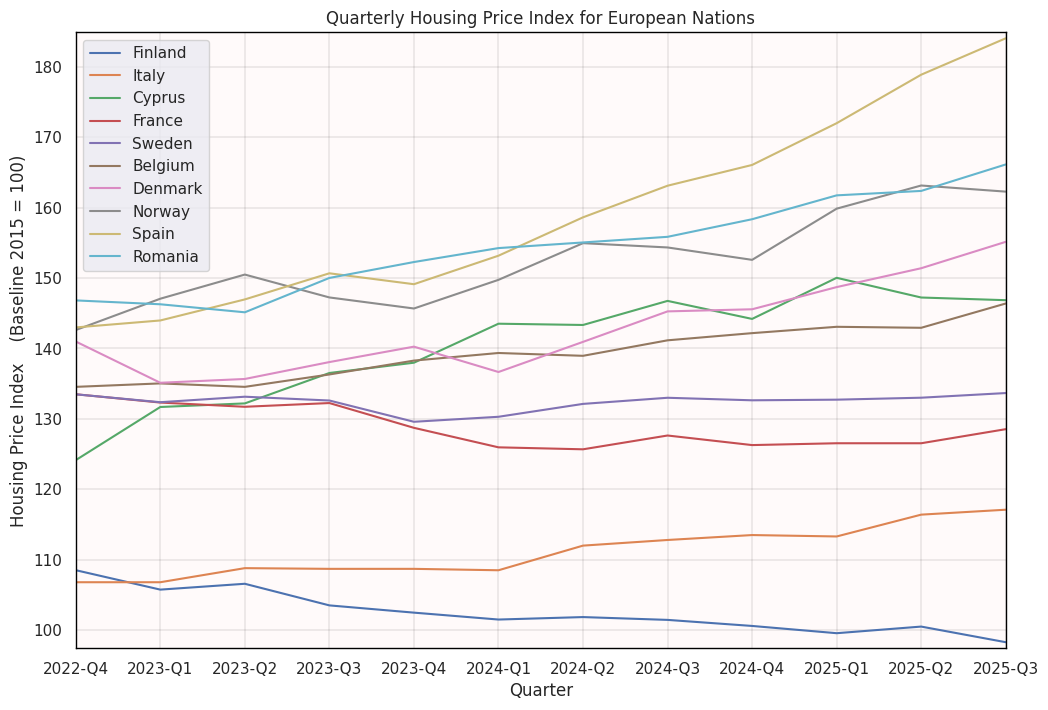

In [120]:
# graph quarterly housing price index for european nations (lowest 10)

fig, ax = plt.subplots(figsize=(12, 8))

# for each country, plot their price_index as a line on ax
for i, country in enumerate(df.sort_values(by='price_index')['country'].unique()[:10]):
  temp = df[df['country'] == country]['price_index'].reset_index(drop=True)
  temp.plot(ax=ax, label=country)

# set labels etc.
_ = ax.set(
    title = 'Quarterly Housing Price Index for European Nations',
    xticks = df['quarter_id'].unique(),
    xticklabels = df['quarter'].unique(),
    xlabel = 'Quarter',
    ylabel = 'Housing Price Index    (Baseline 2015 = 100)'
)

# set up grid lines, margins
ax.grid(color='black', linestyle='-', linewidth=0.1)
ax.set_facecolor('snow')
ax.margins(x=0, y=0.01)

# set spine to black
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

# turn on legend
ax.legend()

From a glance, we can see some countries like Spain and Romania appear to be trending up quite consistently. The price index for France seems to be stagnating after taking a dip over the latter half of 2024. Finland looks like it's slowly trending down.

Another notable detail here is that only 2 countries have records below the baseline price index: Italy and Finland. It seems prices in Italy have since recovered, but Finland still has prices lower than they were in 2015.

Now let's plot the 10 countries with the highest price index from 2022-Q4 to 2025-Q3:



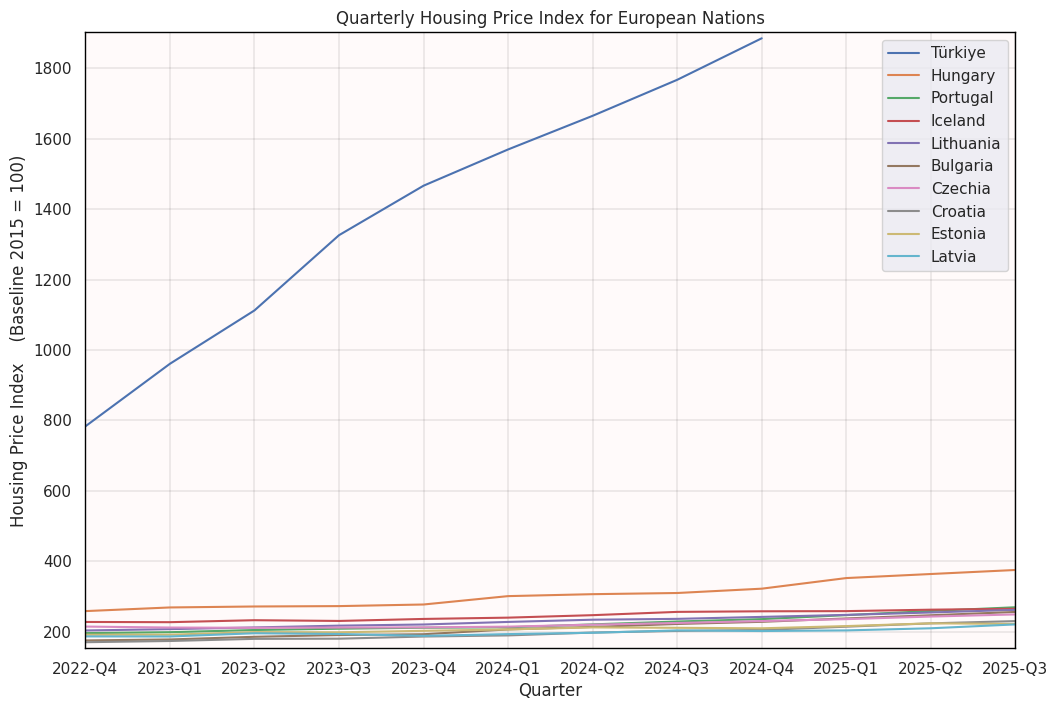

In [121]:
# graph quarterly housing price index for european nations (highest 10)

fig, ax = plt.subplots(figsize=(12, 8))

# for each country, plot their price_index as a line on ax
for i, country in enumerate(df.sort_values(by='price_index', ascending=False)['country'].unique()[:10]):
  temp = df[df['country'] == country]['price_index'].reset_index(drop=True)
  temp.plot(ax=ax, label=country)

# set labels etc.
_ = ax.set(
    title = 'Quarterly Housing Price Index for European Nations',
    xticks = df['quarter_id'].unique(),
    xticklabels = df['quarter'].unique(),
    xlabel = 'Quarter',
    ylabel = 'Housing Price Index    (Baseline 2015 = 100)'
)

# set up grid lines, margins
ax.grid(color='black', linestyle='-', linewidth=0.1)
ax.set_facecolor('snow')
ax.margins(x=0, y=0.01)

# set spine to black
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

# turn on legend
ax.legend()

Wow... Housing in Türkiye has been getting expensive by the look of things.

Let's try plotting again without Türkiye to get a better look at the other countries:

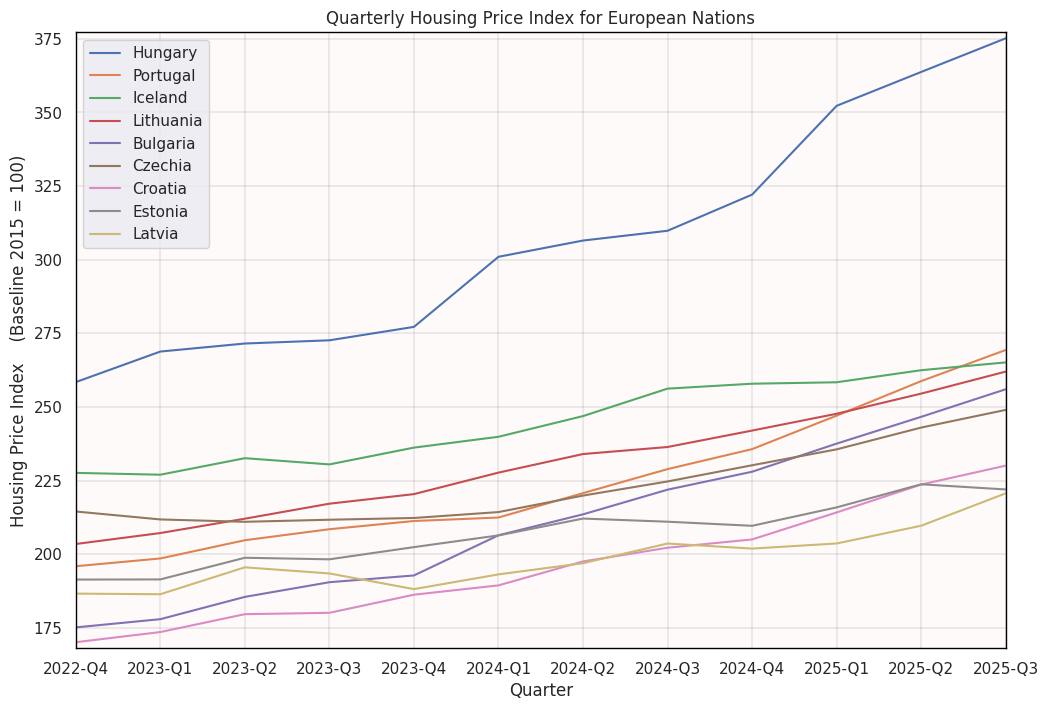

In [122]:
# graph quarterly housing price index for european nations (highest 10 excluding turkiye)

fig, ax = plt.subplots(figsize=(12, 8))

# for each country, plot their price_index as a line on ax
for i, country in enumerate(df.sort_values(by='price_index', ascending=False)['country'].unique()[1:10]):
  temp = df[df['country'] == country]['price_index'].reset_index(drop=True)
  temp.plot(ax=ax, label=country)

# set labels etc.
_ = ax.set(
    title = 'Quarterly Housing Price Index for European Nations',
    xticks = df['quarter_id'].unique(),
    xticklabels = df['quarter'].unique(),
    xlabel = 'Quarter',
    ylabel = 'Housing Price Index    (Baseline 2015 = 100)'
)

# set up grid lines, margins
ax.grid(color='black', linestyle='-', linewidth=0.1)
ax.set_facecolor('snow')
ax.margins(x=0, y=0.01)

# set spine to black
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

# turn on legend
ax.legend()

 Looks like many of these higher index countries have been trending up. This is especially true for Hungary, and I probably wouldn't have noticed if I didn't filter out Türkiye.

 ### Grabbing specific records from our dataset
 If we're looking for specific values in our dataset, we can just grab those using Pandas methods. For example, I'll grab the country, price index and quarter for two records: The lowest price index in the dataset, and the lowest price index for France:

In [123]:
# get highest price index value in our dataset
min = df[df['price_index'] == df['price_index'].min()]
min = min[['country', 'price_index', 'quarter']]
print("Lowest price index in dataset:")
display(min.style.hide(axis="index"))

# get lowest price index value for France in our dataset
france = df[df['country'] == 'France']
france = france[france['price_index'] == france['price_index'].min()][['country', 'price_index', 'quarter']]
print("\n\nLowest price index for France:")
display(france.style.hide(axis="index"))

Lowest price index in dataset:


country,price_index,quarter
Finland,98.280000,2025-Q3




Lowest price index for France:


country,price_index,quarter
France,125.680000,2024-Q2


It's also possible to extract any of these values from their DataFrames to access them programmatically within our Python code. That way, we could store them in a file or use them as part of a larger application.

Here's an example of calculating the percent change of the Housing Price Index in France from 2022-Q4 to 2024-Q2:

In [124]:
# get the value of highest price index for France from previous code cell
lowest_pi_france = france['price_index'].iloc[0]
lowest_quarter_france = france['quarter'].iloc[0]

# compare to first quarter on record in our dataset
first_pi_france = df[(df['country'] == 'France') & (df['quarter_id'] == 0)]['price_index'].iloc[0]
first_quarter_france = df[(df['country'] == 'France') & (df['quarter_id'] == 0)]['quarter'].iloc[0]

print(f"Housing Price Index percent change in France from {first_quarter_france} to {lowest_quarter_france}:")
print(f"{(lowest_pi_france - first_pi_france) / first_pi_france * 100:.4f}%")

Housing Price Index percent change in France from 2022-Q4 to 2024-Q2:
-5.8577%


---

## 4) Trend Estimation
Now that we've had a look at the data, let's perform some analysis in order to uncover meaningful insights, starting with the long-term trend.


 ### Linear Trend Estimation
 By using Linear Regression, we can visualize the trend of the Housing Price Index for a country across the full time period. This is useful because it accounts for short-term fluctuations that can make it difficult to discern the trend from raw data alone. Let's use Linear Regression to estimate the linear trend for Finland:

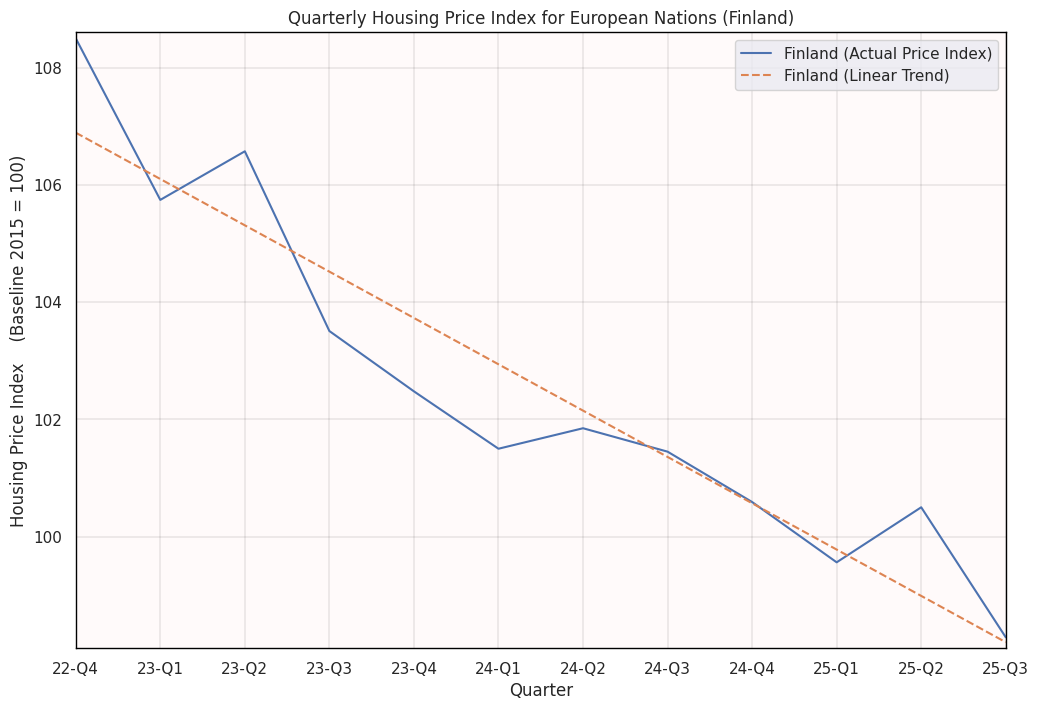

In [125]:
country = 'Finland' # country we want to model

# isolate our country
country_df = df[df['country'] == country]

# isolate our X and y values (quarter_id, price_index)
X = np.array(country_df['quarter_id'].values)
y = np.array(country_df['price_index'].values)

# do linear regression to get our slope and y-intercept
slope, intercept, r_value, p_value, std_err = stats.linregress(X, y)

# generate labels for the x axis
tick_labels = country_df['quarter'].unique().tolist()

# slice off first two digits in quarter labels (helps with legibility)
tick_labels = [label[2:] for label in tick_labels]

# calculate line of best fit
y_pred = intercept + slope * X

# graph quarterly housing price index for country + line of best fit
fig, ax = plt.subplots(figsize=(12, 8))

# plot country's price_index as a line on ax
country_df = country_df['price_index'].reset_index(drop=True)
country_df.plot(ax=ax, label=f'{country} (Actual Price Index)')

# plot our line of best fit
plt.plot(X, y_pred, label=f'{country} (Linear Trend)', linestyle='--')

# set labels etc.
_ = ax.set(
    title = f'Quarterly Housing Price Index for European Nations ({country})',
    xticks = X,
    xticklabels = tick_labels,
    xlabel = 'Quarter',
    ylabel = 'Housing Price Index    (Baseline 2015 = 100)'
)

# set up grid lines, margins
ax.grid(color='black', linestyle='-', linewidth=0.1)
ax.set_facecolor('snow')
ax.margins(x=0, y=0.01)

# set spine to black
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

# turn on legend
ax.legend()

We can see that the Housing Price Index for Finland appears to be **trending down** in the long-term.

Here's the formula that we calculated to create our line of best fit:

In [126]:
print(f"Line of best fit for {country}:\ny = {slope:.4f}x + {intercept:.4f}")

Line of best fit for Finland:
y = -0.7911x + 106.8978


From this formula alone, we can estimate that Finland's price index is trending downwards at a rate of approximately **0.79 per quarter**.

### Rolling Average

Another tool that can help us understand the trend of our time series data is the **Rolling Average**. This metric is more dynamic than Linear Regression, in that it can show changes in the trend over time while still minimizing noise from market fluctuations:


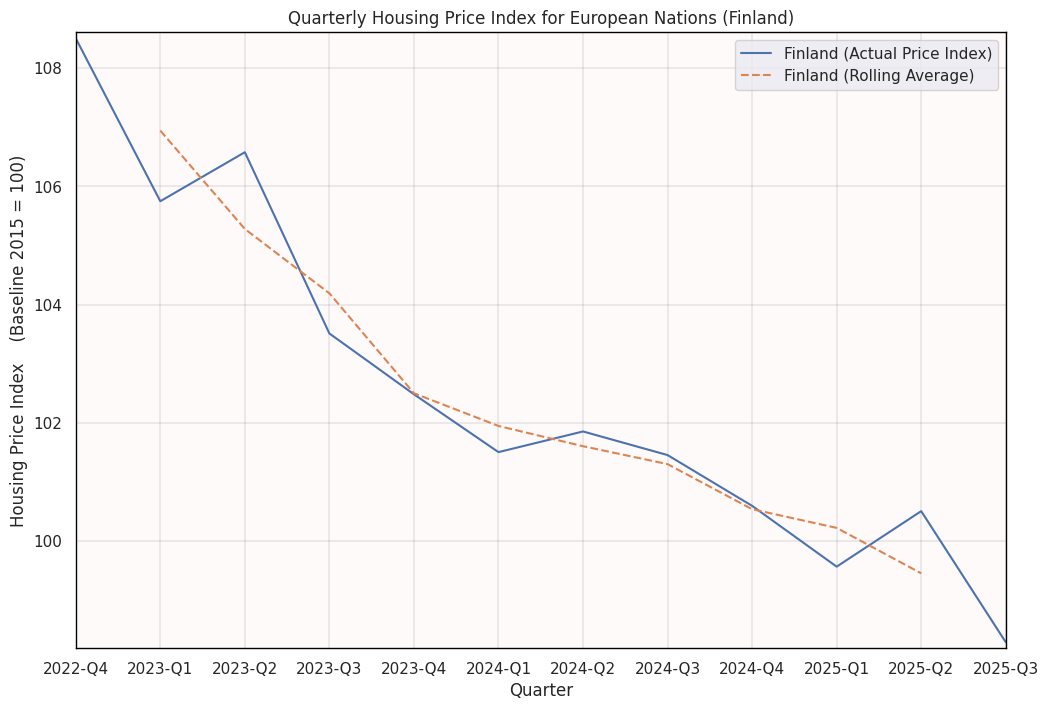

In [127]:
country = 'Finland' # country we want to model
window_size = 3     # window size for rolling average

# isolate our country, X values
country_df = df[df['country'] == country]
X = np.array(country_df['quarter_id'].values)

# calculate rolling average for country's price_index
trend = country_df['price_index'].rolling(window=window_size, center=True).mean()

# generate labels for the x axis
tick_labels = country_df['quarter'].unique().tolist()

# graph quarterly housing price index for country + rolling average
fig, ax = plt.subplots(figsize=(12, 8))

# plot country's price_index as a line on ax
plt.plot(X, country_df['price_index'], label=f'{country} (Actual Price Index)')

# plot our rolling average
plt.plot(X, trend, label=f'{country} (Rolling Average)', linestyle='--')

# set labels etc.
_ = ax.set(
    title = f'Quarterly Housing Price Index for European Nations ({country})',
    xticks = X,
    xticklabels = tick_labels,
    xlabel = 'Quarter',
    ylabel = 'Housing Price Index    (Baseline 2015 = 100)'
)

# set up grid lines, margins
ax.grid(color='black', linestyle='-', linewidth=0.1)
ax.set_facecolor('snow')
ax.margins(x=0, y=0.01)

# set spine to black
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

# turn on legend
ax.legend()

From a glance, we can see more information about the trend in the price index for Finland. For example, we can now see that the trend is **decreasing more sharply** up until the last quarter of 2023, which wasn't visible in our line of best fit.

Please note that because of the windowing in our rolling average, you can see missing values for the first and last quarter on record. This is simply a byproduct of how the rolling average is computed.

### Notes on other methods
I considered using STL decomposition to explore the trend, seasonality and residuals for the price index. This could be more viable if we had at least 24 samples to work with, but since we're focusing on individual countries with at most 12 samples each, I opted against using it due to concerns around possible overfitting.

---

## 5) Forecasting Future Values
Let's do some forecasting for Finland's Housing Price Index over the next 3 quarters. I was intially going to use a machine learning model to do this, but this dataset has a clear limitation: **The sample size.** Because each country has at most 12 samples to train on, I found in my testing that using a simpler statistical model gave better results.

#### Exponential Smoothing

Exponential Smoothing is a statistical model that focuses on past data points to predict future data points. Unlike Linear Regression or Rolling Average, it's **more adaptive to recent patterns** and is a better choice for capturing short-term trends, rather than weighing older and newer data points equally.

There's 3 main types of Exponential Smoothing, but I'll be using **Double Exponential Smoothing** (Holt's method) for two reasons:
1. It's effective at modeling for data with a clear trend (negative trend in the case of Finland)
2. It doesn't factor in seasonality (which would likely require more samples to accurately account for)

#### Additive vs Multiplicative Trend

Before we can start, we want to determine whether our data's trend is additive (linear) or multiplicative (exponential). This is important so that we can maximize the accuracy of our forecasting, since Holt's method expects us to specify the trend as either additive or multiplicative.

I'm going to use the "Horserace" method to do this. This involves running Exponential Smoothing twice, expecting either an additive or multiplicative trend. Then, we run forecasts for existing data points, and compare the results of both methods to the actual data. Whichever method has the lowest error is the one we'll use for our final forecast:

In [128]:
country = 'Finland' # country we want to model

# isolate given country
country_df = df[df['country'] == country].copy()

# Convert 'quarter' to a PeriodIndex and set as index to avoid ValueWarnings
country_df['quarter'] = pd.PeriodIndex(country_df['quarter'], freq='Q')
country_df = country_df.set_index('quarter')


# set up time series split
cv = TimeSeriesSplit(n_splits=5)
errors = {'add': [], 'mul': []}

# for each training record, test record in our time series split
for train_index, test_index in cv.split(country_df):
  train, test = country_df.iloc[train_index], country_df.iloc[test_index]

  # run model with additive trend
  model_add = ExponentialSmoothing(train['price_index'], trend='add', seasonal=None)
  pred_add = model_add.fit().forecast(len(test))
  errors['add'].append(np.sqrt(mean_squared_error(test['price_index'], pred_add)))

  # run model with multiplicative trend
  model_mul = ExponentialSmoothing(train['price_index'], trend='mul', seasonal=None)
  pred_mul = model_mul.fit().forecast(len(test))
  errors['mul'].append(np.sqrt(mean_squared_error(test['price_index'], pred_mul)))


# select the better trend for use in our final forecast
trend = ''

if np.mean(errors['add']) < np.mean(errors['mul']):
  trend = 'additive'
else:
  trend = 'multiplicative'

# print results
print(f"Average Additive RMSE: {np.mean(errors['add']):.4f}")
print(f"Average Multiplicative RMSE: {np.mean(errors['mul']):.4f}")
print(f"'{trend}' trend performs better for {country}.")

Average Additive RMSE: 1.8174
Average Multiplicative RMSE: 1.7257
'multiplicative' trend performs better for Finland.


After running the above code block, we can see that multiplicative trend performs better for Finland when used to predict our existing data. The lower the Root Mean Squared Error (RMSE), the better the model performed.

Now, we can use this information to perform our actual forecasting with the better model:

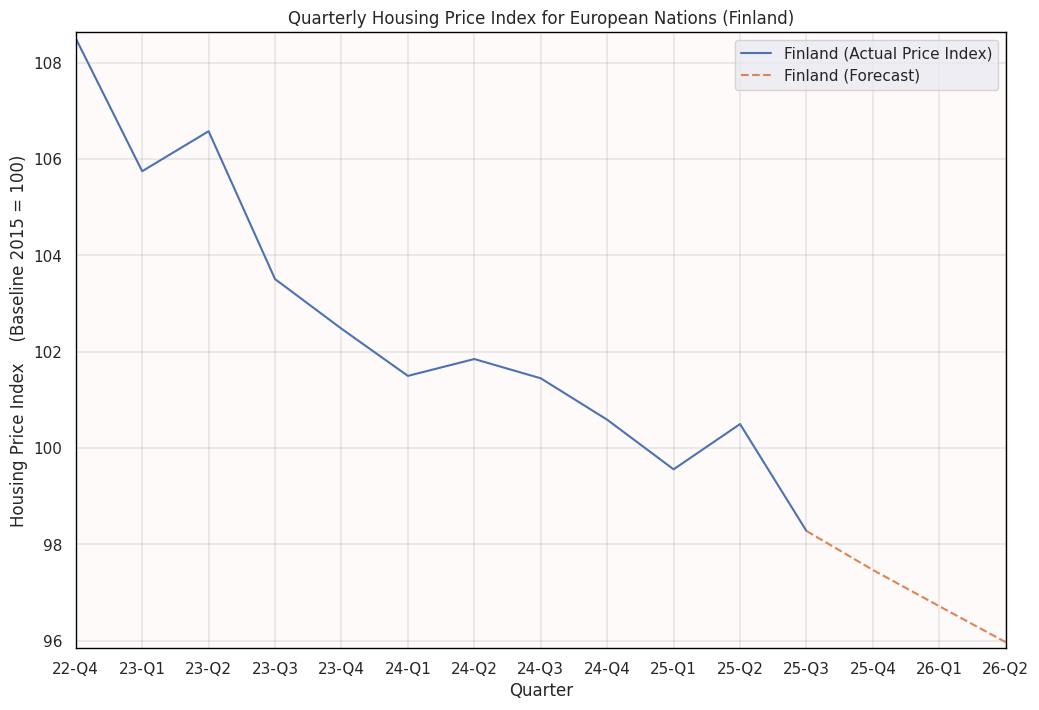

In [129]:
future_quarters = 3 # how many future quarters to model

# isolate our country
country_df = df[df['country'] == country]

# isolate our x and y values (quarter_id, price_index)
X = np.array(country_df['quarter_id'].values)
y = np.array(country_df['price_index'].values)

# generate labels for the x axis
tick_labels = country_df['quarter'].unique().tolist()
for i in range(future_quarters):

  # get last values for year, quarter
  quarter = country_df['quarter_num'].iloc[-1]
  year = country_df['year'].iloc[-1]

  # generate new values
  year += (quarter + i) // 4
  quarter = (quarter + i) % 4 + 1

  # add to list
  tick_labels.append(f"{year}-Q{quarter}")

# slice off first two digits in quarter labels (helps with legibility)
tick_labels = [label[2:] for label in tick_labels]

# extend x to model future quarters
# we'll just use np.arange with count of records + future quarters
X = np.arange(len(country_df) + future_quarters)

# create and fit ExponentialSmoothing model
model = ExponentialSmoothing(
    y,
    trend=trend, # specify our trend based on our test results from previous block
    seasonal=None # specify the lack of a seasonal component (forces Holt's method)
)
fit = model.fit()

# predict future quarters using model
forecast = fit.forecast(future_quarters)

# add last real data point start of 'forecast' to form a continuous line
forecast = np.append(y[-1:], forecast)

# graph quarterly housing price index for country + exponential smoothing forecasting
fig, ax = plt.subplots(figsize=(12, 8))

# plot country's price_index as a line on ax
country_df = country_df['price_index'].reset_index(drop=True)
country_df.plot(ax=ax, label=f'{country} (Actual Price Index)')

# plot our forecasted values
plt.plot(X[-future_quarters-1:], forecast, label=f'{country} (Forecast)', linestyle='--')

# set labels etc.
_ = ax.set(
    title = f'Quarterly Housing Price Index for European Nations ({country})',
    xticks = X,
    xticklabels = tick_labels,
    xlabel = 'Quarter',
    ylabel = 'Housing Price Index    (Baseline 2015 = 100)'
)

# set up grid lines, margins
ax.grid(color='black', linestyle='-', linewidth=0.1)
ax.set_facecolor('snow')
ax.margins(x=0, y=0.01)

# set spine to black
for spine in ax.spines.values():
    spine.set_edgecolor('black')
    spine.set_linewidth(1)

# turn on legend
ax.legend()

As we can see in the plot, our forecast predicts that housing prices for Finland **will continue to fall** in the final quarter of 2025 and into 2026. Here are the specific values we predicted for the next three quarters:

In [130]:
for i, value in enumerate(forecast[-3:]):
  print(f"20{tick_labels[-3+i]}: {value:.4f}")

2025-Q4: 97.4703
2026-Q1: 96.7173
2026-Q2: 95.9701


#### A Note on the Forecasting Results
I'd like to note that although we don't have enough samples to determine seasonality, there appears to be a **consistent increase** in Finland's price index in the 2nd quarter of each year. This should lead us to question the accuracy of our forecast, since it doesn't include that bump as it passes into 2026-Q2. Despite this small detail, it's still reasonable to expect the trend to continue downwards based on these results.

If our dataset had more samples, I would opt to use **Triple Exponential Smoothing** instead, which should be capable of accounting for that yearly fluctuation in prices.

---

##6) Correlation Mapping

Although we've been able to do some simple forecasting with Exponential Smoothing, it's important to remember that this forecast only takes past price index values into account. Since housing prices are an economic variable, it's reasonable to assume that **external factors may also play a significant role** in potential future prices.

Since our dataset includes other variables, we can use Seaborn to create a **Correlation Heatmap** to visualize the correlation between each variable:

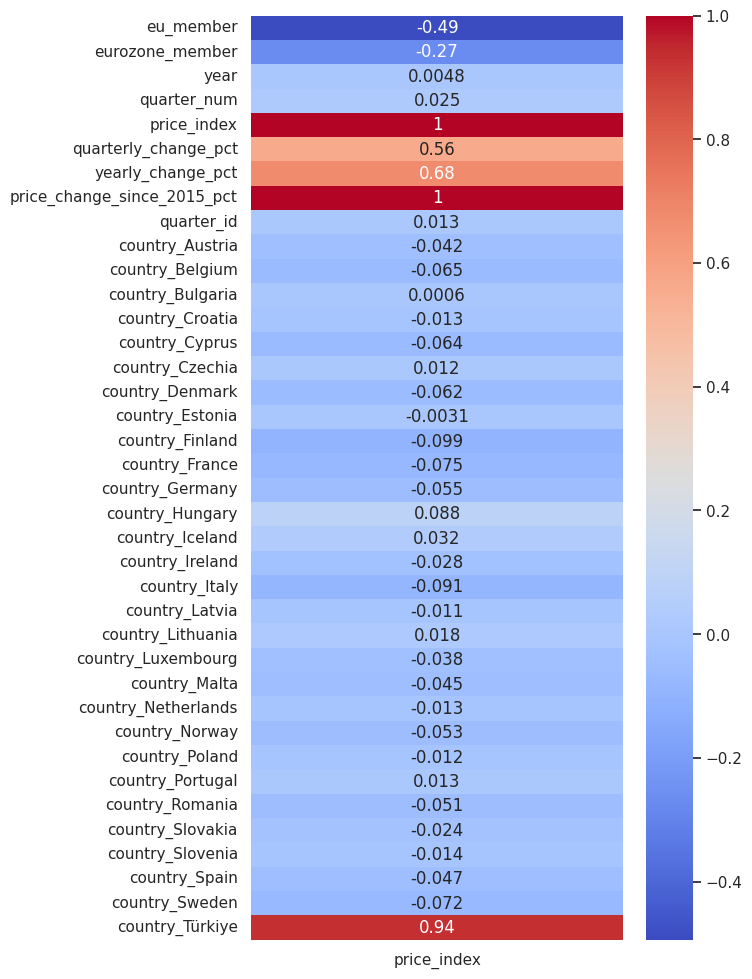

In [131]:
# make a copy of our dataframe for our heatmap
heatmap_df = df.copy()

# one hot encode fields 'country'
heatmap_df = pd.get_dummies(heatmap_df, columns=['country'], dtype=int)

# encode eu_member and eurozone_member as numeric values (0 or 1)
heatmap_df['eu_member'] = heatmap_df['eu_member'].map({'No': 0, 'Yes': 1}).astype(int)
heatmap_df['eurozone_member'] = heatmap_df['eurozone_member'].map({'No': 0, 'Yes': 1}).astype(int)


# drop remaining fields that aren't numerically encoded
fields_to_drop = [
    "quarter"
]
heatmap_df.drop(columns=fields_to_drop, inplace=True)

# create our correlation matrix
corr_matrix = heatmap_df.corr()

# plot our correlation matrix as a heatmap
sns.set_theme(rc={'figure.figsize':(6,12)})
sns.heatmap(corr_matrix[['price_index']], annot=True, cmap='coolwarm')
plt.show()

I decided to one-hot encode the countries in our correlation DataFrame, which is common in preparing a dataset for machine learning applications. This lets us visualize the individual impact of each country on the *price_index*, rather than providing an aggregated correlation for every country. Since we've got so many one-hot country fields, I've extracted the row that correlates with the Housing Price Index to make the chart easier to read.

From looking at the heatmap, we can see that the majority of country fields have a relatively small impact on the *price_index* (except for Türkiye, which is because of how extreme their prices have become.) We can also see that Finland has the strongest negative correlation, which makes sense given what we've seen so far.

Let's try again without the country fields, so we can focus on the impact of the other variables:

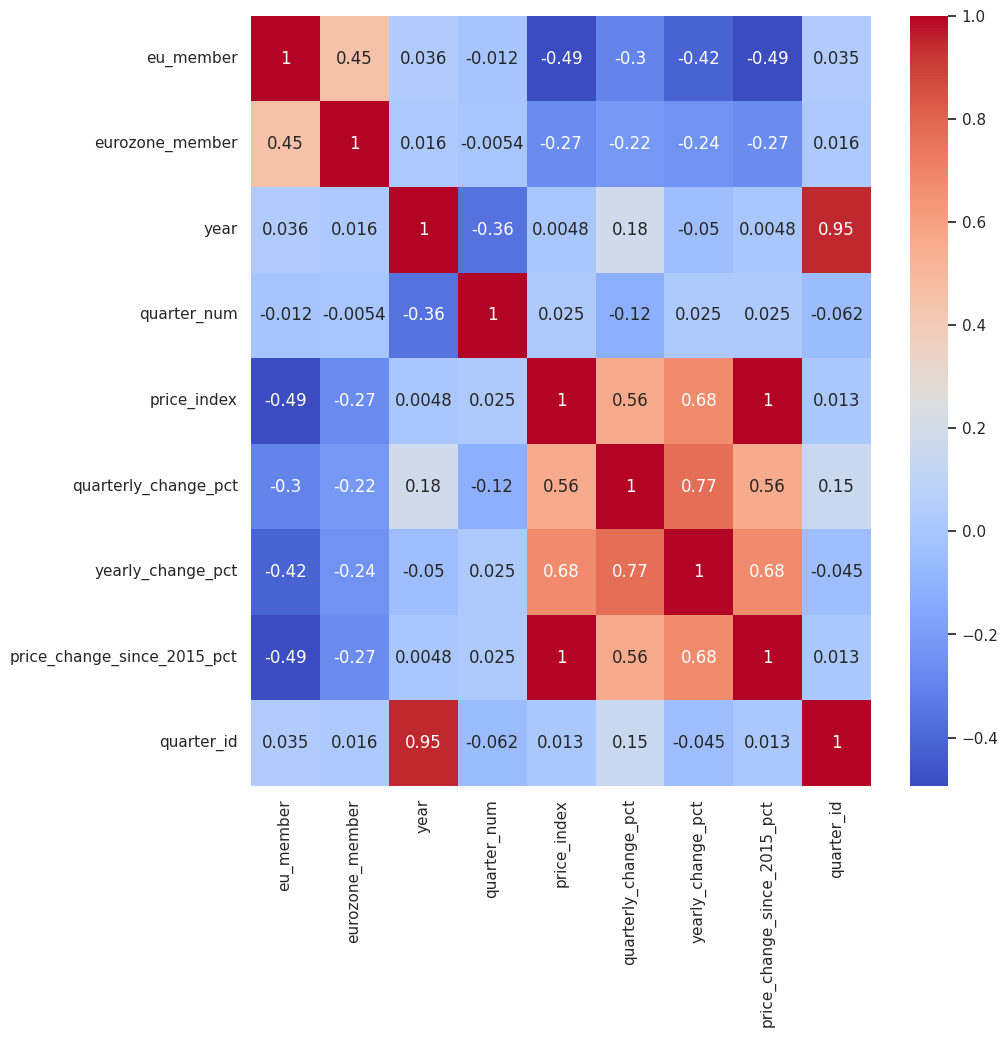

In [132]:
# make a copy of our dataframe for our heatmap
heatmap_df = df.copy()

# encode eu_member and eurozone_member as numeric values (0 or 1)
heatmap_df['eu_member'] = heatmap_df['eu_member'].map({'No': 0, 'Yes': 1}).astype(int)
heatmap_df['eurozone_member'] = heatmap_df['eurozone_member'].map({'No': 0, 'Yes': 1}).astype(int)


# drop remaining fields that aren't numerically encoded
fields_to_drop = [
    "quarter",
    "country"
]
heatmap_df.drop(columns=fields_to_drop, inplace=True)

# create correlation matrix
corr_matrix = heatmap_df.corr()

# plot our correlation matrix as a heatmap
sns.set_theme(rc={'figure.figsize':(10, 10)})
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.show()

From this chart, it's clear that the 3 variables in our dataset that correlate the most with *price_index*  would be **EU membership**, **Eurozone membership** and **which quarter** of which year the index corresponds to.

Even though the percentage (pct) variables show a very high correlation with the price index, It's important to remember that they aren't useful predictors for future prices, since they're calculated based on the current *price_index* itself.

Based on these results, we also get some valuable insights:
1. EU membership is correlated with a **lower Housing Price Index**
2. Eurozone membership is also correlated with a **lower Housing Price Index** (though not as strongly as EU membership)

These insights could be used to improve our forecasting. For example, if we had access to more data for training, we could train a more effective ML model that takes EU and Eurozone membership into account.

---

##7) Key Insights

Below are the insights we've uncovered through our analysis:

####Insights about Finland:
- Finland is the only country in Europe which has maintained housing prices lower than they were in 2015.
- Finland has shown a **consistent downward trend** in housing prices.
- The trend in Finnish prices has seen a **sharper decrease** prior to 2023-Q4, before slowing down in 2024 and onward.
- Finland appears to have a seasonal increase in prices in Q2 each year, which does not affect long-term trends.
- Using Holt's method, we've forecasted that Finland's housing prices **will continue to fall** in the next few quarters.


####Insights across all countries:
- Growth rates in housing prices vary significantly across countries.
- Many countries see prices trending upwards, others trending downwards.
- Limited data for each country restricts detection of seasonal patterns.
- EU and Eurozone members show **lower price index values** than non-members.
- Türkiye shows the **most extreme increase** in housing prices across Europe since 2015.
